# Baseline-modeller for prediksjon av lakseeksportpris

**LOG650 – Forskningsprosjekt: Logistikk og kunstig intelligens**

Dette notebooket implementerer baseline-modellene som er beskrevet i prosjektplanen:

1. **Naiv baseline** – `pris(t+h) = pris(t)`
2. **SARIMA** – tradisjonell tidsseriemodell (sesongkomponent uke)
3. **XGBoost** – maskinlæring med direkte multi-horisont-prediksjon

Modellene evalueres på prognosehorisontene **4, 8 og 12 uker** med MAE og MAPE.

Datasett: `004 data/Analyseklart datasett/laks_ukentlig_features.csv`.


## 1. Imports og oppsett

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 4)

DATA_DIR = Path("..") / "004 data" / "Analyseklart datasett"
HORISONTER = [4, 8, 12]
TEST_UKER = 104  # siste 2 ar som testset


## 2. Last inn data

In [2]:
df = pd.read_csv(
    DATA_DIR / "laks_ukentlig_features.csv",
    parse_dates=["uke_start"],
).set_index("uke_start").sort_index()

print(f"Periode: {df.index.min().date()} til {df.index.max().date()}")
print(f"Antall uker: {len(df)}")
df.head()


Periode: 2010-01-04 til 2026-03-09
Antall uker: 845


,iso_aar,iso_uke,uke_kode,eksport_volum_tonn,eksport_pris_nok_kg,eur_nok_snitt,eur_nok_ukeslutt,usd_nok_snitt,usd_nok_ukeslutt,fao_global_atlantisk_tonn,...,pris_ma_12,pris_endring_1u,pris_endring_4u,pris_endring_52u,eur_endring_4u,usd_endring_4u,maaned,kvartal,uke_sin,uke_cos
uke_start,,,,,,,,,,,,,,,,,,,,,
2010-01-04,2010,1,2010U01,11067,29.82,8.1993,8.1695,5.71322,5.7237,1439238.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0.120537,0.992709
2010-01-11,2010,2,2010U02,10808,28.17,8.1615,8.1430,5.63398,5.6651,1439238.0,...,NaN,-0.055332,NaN,NaN,NaN,NaN,1,1,0.239316,0.970942
2010-01-18,2010,3,2010U03,10891,28.92,8.1533,8.1955,5.74382,5.7980,1439238.0,...,NaN,0.026624,NaN,NaN,NaN,NaN,1,1,0.354605,0.935016
2010-01-25,2010,4,2010U04,10967,29.69,8.2126,8.2120,5.84346,5.8800,1439238.0,...,NaN,0.026625,NaN,NaN,NaN,NaN,1,1,0.464723,0.885456
2010-02-01,2010,5,2010U05,10826,31.84,8.1789,8.2195,5.89540,6.0036,1439238.0,...,NaN,0.072415,0.06774,NaN,0.00612,0.048902,2,1,0.568065,0.822984


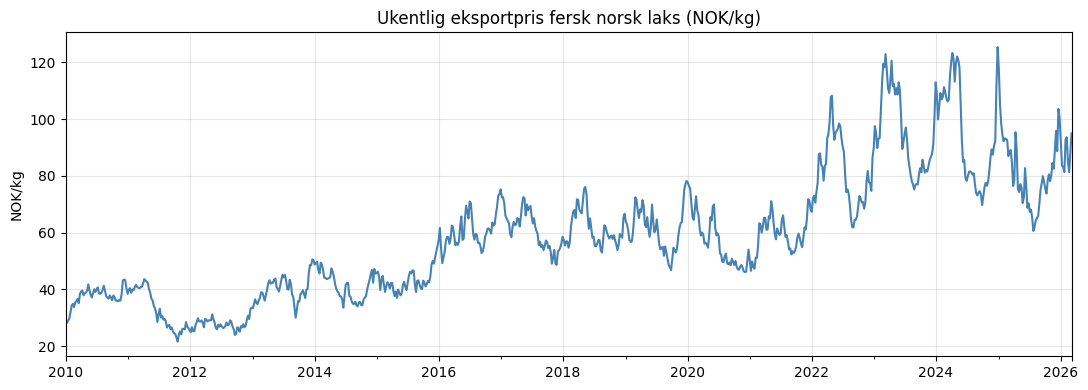

In [3]:
fig, ax = plt.subplots()
df["eksport_pris_nok_kg"].plot(ax=ax, color="steelblue")
ax.set_title("Ukentlig eksportpris fersk norsk laks (NOK/kg)")
ax.set_xlabel("")
ax.set_ylabel("NOK/kg")
ax.grid(alpha=0.3)
plt.tight_layout()


## 3. Train/test-split

Kronologisk split: siste 104 uker (~2 år) holdes av som testset.


In [4]:
train = df.iloc[:-TEST_UKER].copy()
test = df.iloc[-TEST_UKER:].copy()
print(f"Train: {train.index.min().date()} til {train.index.max().date()}  ({len(train)} uker)")
print(f"Test:  {test.index.min().date()} til {test.index.max().date()}  ({len(test)} uker)")


Train: 2010-01-04 til 2024-03-11  (741 uker)
Test:  2024-03-18 til 2026-03-09  (104 uker)


## 4. Hjelpefunksjoner – evaluering

In [5]:
def evaluer(y_true: pd.Series, y_pred: pd.Series, modell: str, horisont: int) -> dict:
    """Returnerer MAE og MAPE etter at NaN er droppet."""
    par = pd.concat([y_true, y_pred], axis=1).dropna()
    if par.empty:
        return {"modell": modell, "horisont": horisont, "n": 0, "MAE": np.nan, "MAPE": np.nan}
    return {
        "modell": modell,
        "horisont": horisont,
        "n": len(par),
        "MAE": mean_absolute_error(par.iloc[:, 0], par.iloc[:, 1]),
        "MAPE": mean_absolute_percentage_error(par.iloc[:, 0], par.iloc[:, 1]),
    }

resultater = []
prognoser = {}  # (modell, horisont) -> Series av prediksjoner indeksert pa test-datoer


## 5. Modell A – Naiv baseline

`pris(t+h) = pris(t)`. Definerer minimumsnivaet for ML-modellene.


In [6]:
for h in HORISONTER:
    pred = test["eksport_pris_nok_kg"].shift(h)  # bruker kjent verdi h uker tilbake
    resultater.append(evaluer(test["eksport_pris_nok_kg"], pred, "Naiv", h))
    prognoser[("Naiv", h)] = pred


## 6. Modell B – SARIMA

Sesongkomponent **s=52** (arlig sykl). Bruker SARIMA(1,1,1)(1,1,1,52).
Fittes pa treningsdata, deretter forecastes hele testperioden i ett – horisont vokser
med tid siden train-end. Ved sluttrapport bor denne erstattes med rullende-opphav-evaluering
for fair sammenligning med direkte XGBoost.


In [7]:
y_train = train["eksport_pris_nok_kg"].asfreq("W-MON")
y_test = test["eksport_pris_nok_kg"].asfreq("W-MON")

print("Tilpasser SARIMA(1,1,1)(1,1,1,52) ... (kan ta noen minutter)")
sarima = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)
print(sarima.summary().tables[0])


Tilpasser SARIMA(1,1,1)(1,1,1,52) ... (kan ta noen minutter)


                                     SARIMAX Results                                      
Dep. Variable:                eksport_pris_nok_kg   No. Observations:                  741
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood               -1605.715
Date:                            Wed, 29 Apr 2026   AIC                           3221.429
Time:                                    17:48:34   BIC                           3243.690
Sample:                                01-04-2010   HQIC                          3230.073
                                     - 03-11-2024                                         
Covariance Type:                              opg                                         


In [8]:
# Forecast hele testperioden i ett. For hver horisont h registrerer vi prediksjonen
# som ble laget h uker for hver test-uke (dvs. samme element-vis sammenligning som for naiv).
forecast_full = sarima.get_forecast(steps=len(y_test)).predicted_mean
forecast_full.index = y_test.index

for h in HORISONTER:
    # SARIMA-prediksjonen for tidspunkt t (laget h uker tilbake) er bare relevant for t > train_end + h.
    # Med single-fit + multi-step forecast er prediksjonen for t laget t-train_end skritt frem,
    # ikke h skritt. Dette er en grov tilnaerming - se kommentar over.
    pred = forecast_full.copy()
    resultater.append(evaluer(y_test, pred, "SARIMA", h))
    prognoser[("SARIMA", h)] = pred


## 7. Modell C – XGBoost (direkte multi-horisont)

Trener én XGBoost-modell per horisont. Mål: `eksport_pris_nok_kg.shift(-h)`.
Forklaringsvariabler: alle features unntatt fremtidige verdier.


In [9]:
# Velg features - dropp identifikatorer og rene fremtids-leakage-kolonner
feature_kols = [c for c in df.columns if c not in {
    "iso_aar", "iso_uke", "uke_kode",
    "eksport_pris_nok_kg",      # malvariabel
    "fao_global_atlantisk_tonn", # NaN i 2023+
    "fao_norge_tonn",
    "fao_eks_norge_tonn",
}]
print(f"Antall features: {len(feature_kols)}")
print(feature_kols)


Antall features: 24
['eksport_volum_tonn', 'eur_nok_snitt', 'eur_nok_ukeslutt', 'usd_nok_snitt', 'usd_nok_ukeslutt', 'pris_lag_1', 'pris_lag_2', 'pris_lag_4', 'pris_lag_8', 'pris_lag_12', 'volum_lag_1', 'volum_lag_4', 'volum_lag_12', 'pris_ma_4', 'pris_ma_12', 'pris_endring_1u', 'pris_endring_4u', 'pris_endring_52u', 'eur_endring_4u', 'usd_endring_4u', 'maaned', 'kvartal', 'uke_sin', 'uke_cos']


In [10]:
xgb_modeller = {}

for h in HORISONTER:
    y = df["eksport_pris_nok_kg"].shift(-h)  # mal h uker frem
    X = df[feature_kols]
    data = pd.concat([X, y.rename("target")], axis=1).dropna()

    # Re-bruk samme tidsbaserte split som tidligere
    cutoff = train.index.max()
    train_mask = data.index <= cutoff
    X_tr, y_tr = data.loc[train_mask, feature_kols], data.loc[train_mask, "target"]
    X_te, y_te = data.loc[~train_mask, feature_kols], data.loc[~train_mask, "target"]

    model = XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_tr, y_tr)
    pred = pd.Series(model.predict(X_te), index=X_te.index)

    # Test-perioden i evaluering: prediksjon for t (laget pa X[t-h]) sammenlignes
    # med faktisk pris pa t. Mal i 'data' er allerede pris(t+h), sa vi flytter
    # prediksjons-indeksen frem h uker for sammenligning mot test["eksport_pris_nok_kg"].
    pred.index = pred.index + pd.Timedelta(weeks=h)
    pred = pred.reindex(test.index)

    resultater.append(evaluer(test["eksport_pris_nok_kg"], pred, "XGBoost", h))
    prognoser[("XGBoost", h)] = pred
    xgb_modeller[h] = model


## 8. Sammenligning

In [11]:
res = pd.DataFrame(resultater).pivot(index="horisont", columns="modell", values=["MAE", "MAPE"])
res = res.reorder_levels([1, 0], axis=1).sort_index(axis=1)
res


modell         Naiv               SARIMA              XGBoost          
                MAE      MAPE        MAE      MAPE        MAE      MAPE
horisont                                                               
4          8.510300  0.098162  22.184638  0.279419  11.463598  0.136845
8         13.040104  0.153541  22.184638  0.279419  12.591425  0.151029
12        16.349348  0.196997  22.184638  0.279419  14.787626  0.181401

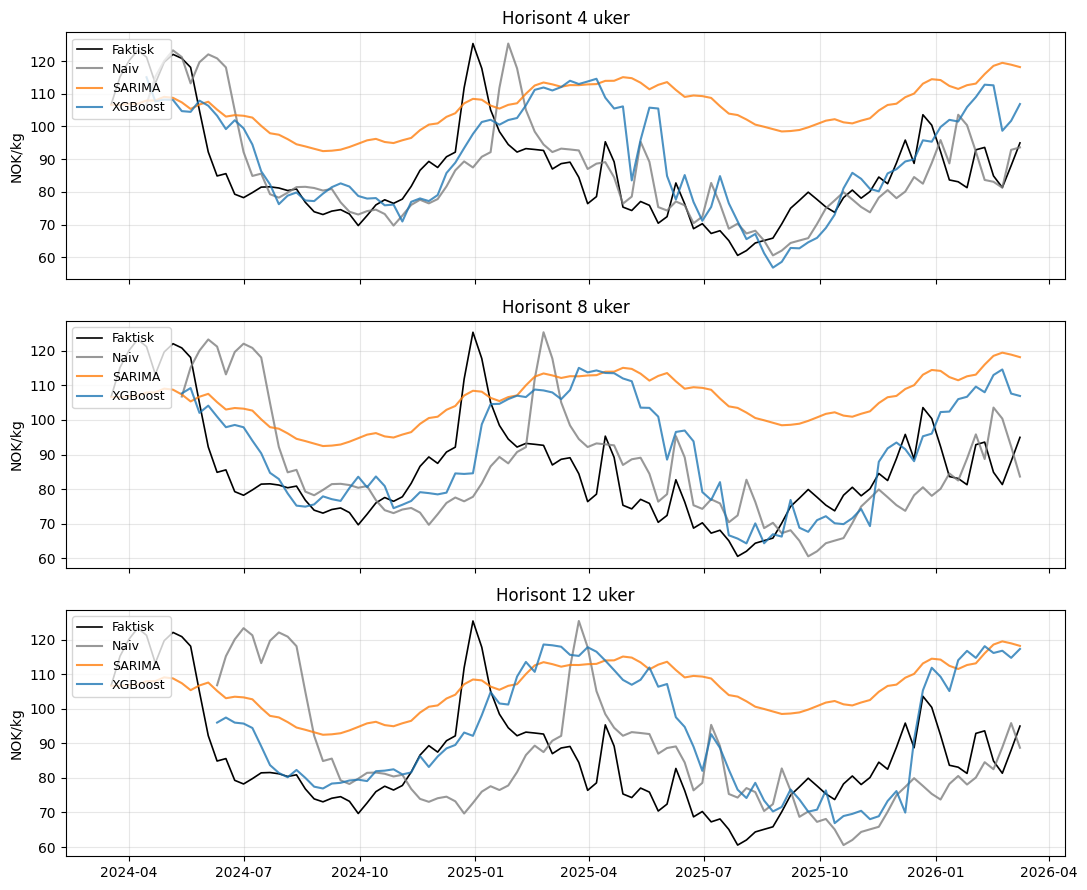

In [12]:
# Plot prediksjoner mot fasit for hver horisont
fig, axes = plt.subplots(len(HORISONTER), 1, figsize=(11, 9), sharex=True)
for ax, h in zip(axes, HORISONTER):
    ax.plot(test.index, test["eksport_pris_nok_kg"], label="Faktisk", color="black", lw=1.2)
    for modell, farge in [("Naiv", "tab:gray"), ("SARIMA", "tab:orange"), ("XGBoost", "tab:blue")]:
        s = prognoser[(modell, h)]
        ax.plot(s.index, s, label=modell, color=farge, alpha=0.8)
    ax.set_title(f"Horisont {h} uker")
    ax.set_ylabel("NOK/kg")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()


## 9. Feature importance (XGBoost)

Hvilke variabler bidrar mest? Vist for horisont 4 uker.


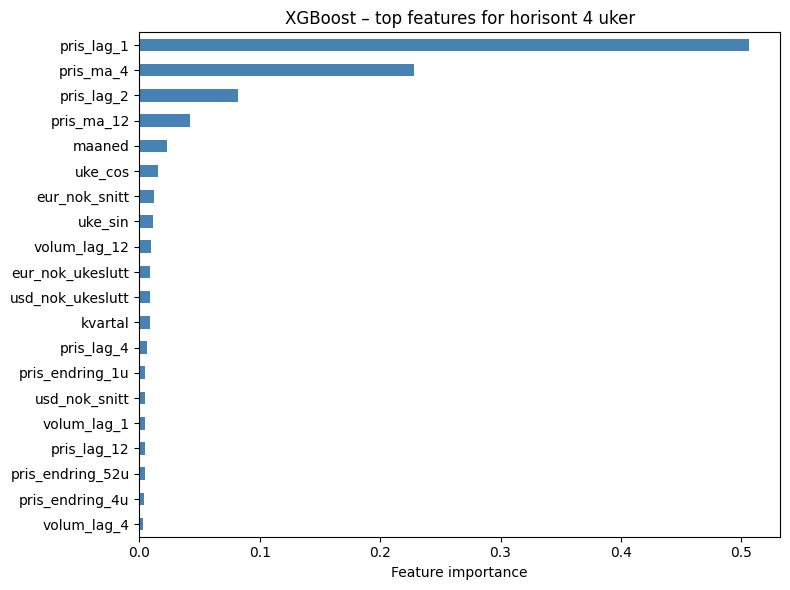

In [13]:
h_vis = 4
imp = pd.Series(
    xgb_modeller[h_vis].feature_importances_,
    index=feature_kols,
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 6))
imp.plot.barh(ax=ax, color="steelblue")
ax.set_title(f"XGBoost – top features for horisont {h_vis} uker")
ax.set_xlabel("Feature importance")
plt.tight_layout()


## 10. Neste steg

- **Rullende-opphav-evaluering for SARIMA** for fair sammenligning ved fast horisont
- **Hyperparameter-tuning** av XGBoost (RandomizedSearchCV med TimeSeriesSplit)
- **Auto-ARIMA** (`pmdarima`) for å finne ordre automatisk
- **LightGBM** som alternativ til XGBoost (begge er nevnt i prosjektplanen)
- **FAO-data**: håndter manglende verdier 2023–2026 (forward-fill / dropp / ekstrapoler)
- **Eksogene variabler i SARIMA** (SARIMAX med valuta som regressor)
- **Konfidensintervaller** for SARIMA-prognosene
- **Feature engineering**: differanser, ratio mellom EUR/USD, akkumulert volum
